In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('referrals_past_data.csv')
df.head()

,Month,Referrals_Received
0,Jan-23,163719
1,Feb-23,148669
2,Mar-23,167407
3,Apr-23,129753
4,May-23,146659


In [ ]:
df.shape

(38, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Month               38 non-null     object
 1   Referrals_Received  38 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 740.0+ bytes


In [ ]:
df['Month'] = pd.to_datetime(df['Month'], format='%b-%y')
print("Datatype of Month Column = ",df['Month'].dtype)

Datatype of Month Column =  datetime64[ns]


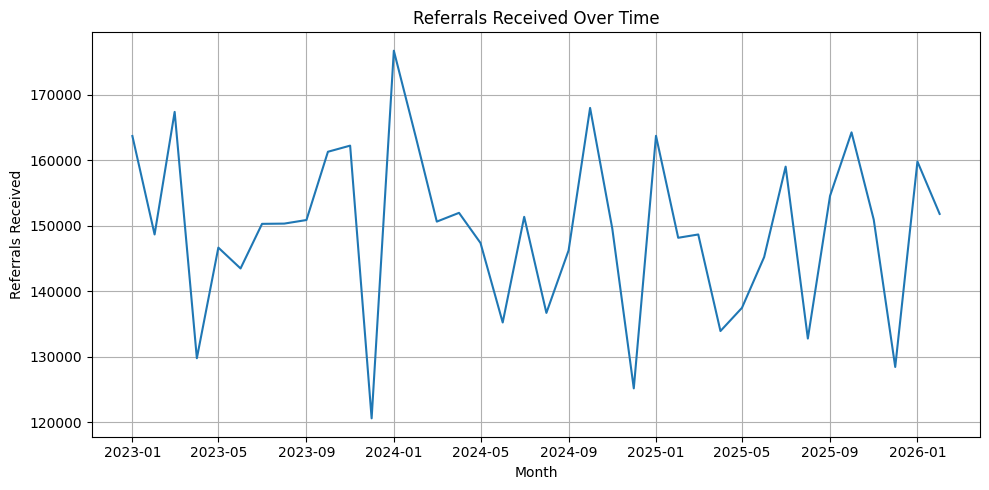

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Month', y='Referrals_Received')
plt.title('Referrals Received Over Time')
plt.xlabel('Month')
plt.ylabel('Referrals Received')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
split_date = df['Month'].max() - pd.DateOffset(months=6)

train_df = df[df['Month'] <= split_date]
test_df = df[df['Month'] > split_date]

print(f"Training data contains {len(train_df)} months up to {train_df['Month'].max().strftime('%Y-%m-%d')}")
print(f"Testing data contains {len(test_df)} months from {test_df['Month'].min().strftime('%Y-%m-%d')}")

Training data contains 32 months up to 2025-08-01
Testing data contains 6 months from 2025-09-01


In [ ]:
from prophet import Prophet

prophet_train_df = train_df[['Month', 'Referrals_Received']].rename(columns={'Month': 'ds', 'Referrals_Received': 'y'})

prophet_model = Prophet()
prophet_model.fit(prophet_train_df)

print("Prophet model trained successfully on the training data.")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 24.


Prophet model trained successfully on the training data.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

prophet_test_df = test_df[['Month', 'Referrals_Received']].rename(columns={'Month': 'ds', 'Referrals_Received': 'y'})

future_prophet = prophet_model.make_future_dataframe(periods=len(prophet_test_df), freq='MS', include_history=False)

prophet_forecast = prophet_model.predict(future_prophet)

prophet_y_true = prophet_test_df['y'].values
prophet_y_pred = prophet_forecast['yhat'].values

prophet_mae = mean_absolute_error(prophet_y_true, prophet_y_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_y_true, prophet_y_pred))

print(f"Prophet MAE on test set: {prophet_mae:.2f}")
print(f"Prophet RMSE on test set: {prophet_rmse:.2f}")

Prophet MAE on test set: 5678.88
Prophet RMSE on test set: 6869.27


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_train_df = train_df.set_index('Month')
arima_order = (2, 1, 2)

print(f"Fitting ARIMA model with order {arima_order} on training data...")
arima_model_eval = ARIMA(arima_train_df['Referrals_Received'], order=arima_order)
arima_results_eval = arima_model_eval.fit()
print("ARIMA model fitted successfully on training data.")

Fitting ARIMA model with order (2, 1, 2) on training data...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA model fitted successfully on training data.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
arima_test_df = test_df.set_index('Month')

arima_forecast_eval = arima_results_eval.predict(start=arima_test_df.index.min(), end=arima_test_df.index.max(), dynamic=False)

arima_y_true = arima_test_df['Referrals_Received'].values
arima_y_pred = arima_forecast_eval.values

arima_mae = mean_absolute_error(arima_y_true, arima_y_pred)
arima_rmse = np.sqrt(mean_squared_error(arima_y_true, arima_y_pred))

print(f"ARIMA MAE on test set: {arima_mae:.2f}")
print(f"ARIMA RMSE on test set: {arima_rmse:.2f}")

ARIMA MAE on test set: 13518.13
ARIMA RMSE on test set: 15499.45


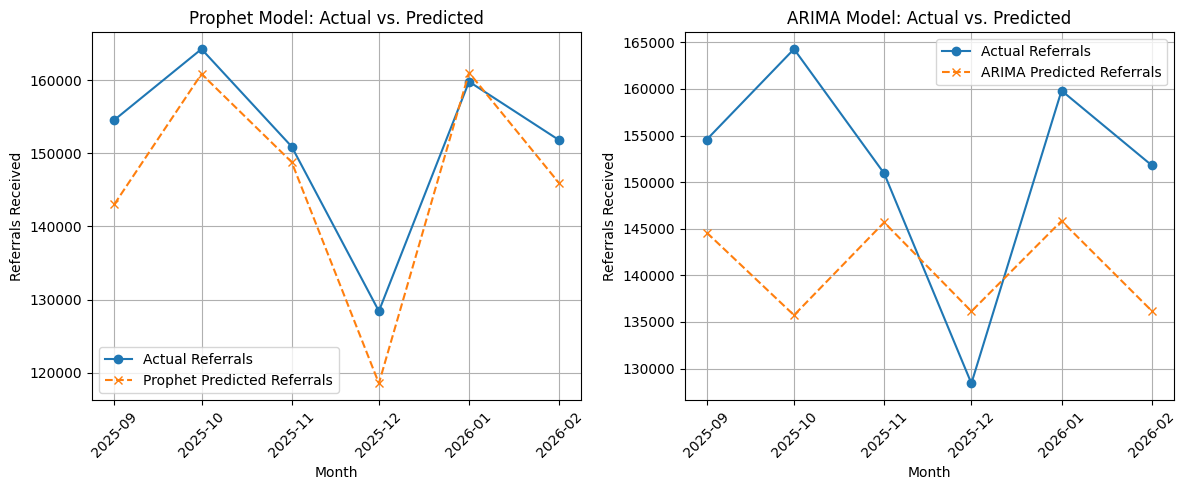

In [ ]:
plt.figure(figsize=(12, 5))

# Prophet Actual vs. Predicted
plt.subplot(1, 2, 1)
plt.plot(prophet_test_df['ds'], prophet_y_true, label='Actual Referrals', marker='o', linestyle='-')
plt.plot(prophet_test_df['ds'], prophet_y_pred, label='Prophet Predicted Referrals', marker='x', linestyle='--')
plt.title('Prophet Model: Actual vs. Predicted')
plt.xlabel('Month')
plt.ylabel('Referrals Received')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# ARIMA Actual vs. Predicted
plt.subplot(1, 2, 2)
plt.plot(arima_test_df.index, arima_y_true, label='Actual Referrals', marker='o', linestyle='-')
plt.plot(arima_test_df.index, arima_y_pred, label='ARIMA Predicted Referrals', marker='x', linestyle='--')
plt.title('ARIMA Model: Actual vs. Predicted')
plt.xlabel('Month')
plt.ylabel('Referrals Received')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
future = prophet_model.make_future_dataframe(periods=len(prophet_test_df) + 3, freq='MS')
forecast = prophet_model.predict(future)

display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3))


,ds,yhat,yhat_lower,yhat_upper
38,2026-03-01,152423.840385,147953.914084,156681.602932
39,2026-04-01,126766.798169,122319.635503,131351.312711
40,2026-05-01,136546.613795,132374.933619,140985.633236


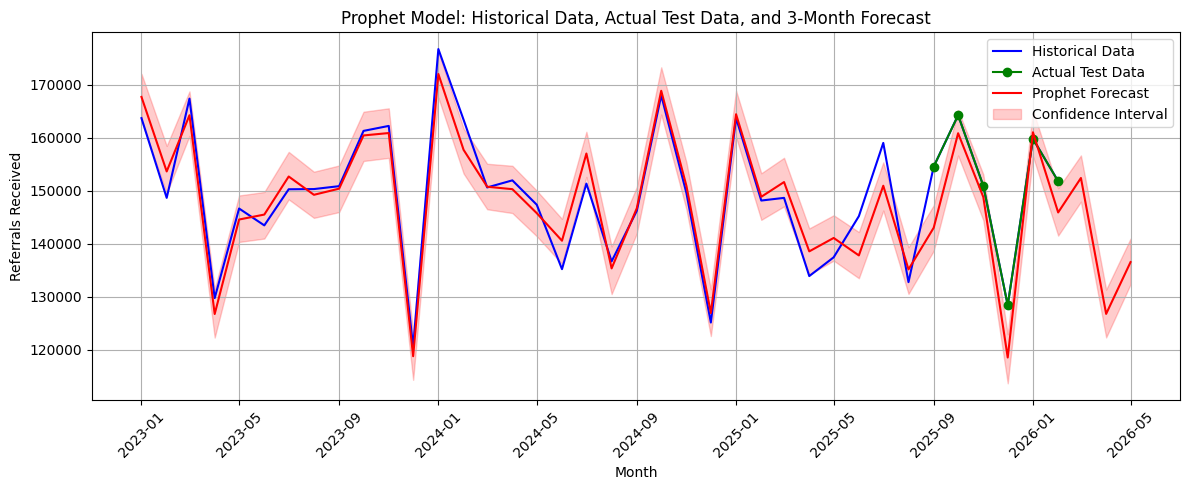

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['Month'], df['Referrals_Received'], label='Historical Data', color='blue')
plt.plot(prophet_test_df['ds'], prophet_y_true, label='Actual Test Data', color='green', marker='o', linestyle='-')
plt.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast', color='red', linestyle='-')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.2, label='Confidence Interval')

plt.title('Prophet Model: Historical Data, Actual Test Data, and 3-Month Forecast')
plt.xlabel('Month')
plt.ylabel('Referrals Received')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()